# TPI 1: Adquisición y Análisis Lingüístico de Medios

**Modalidad:** Trabajo Práctico Individual (calificación numérica de 0 a 10).

**Fecha de entrega y exposición:** Jueves 16 de abril. Se realizará de manera expositiva en remoto frente a todo el grupo de estudiantes (aproximadamente 10 minutos por presentación) para que entre quienes participan veamos posibles soluciones.

**Duración estimada de codificación:** 2 horas

**Desafío general:**
Vas a construir un sistema en Python que adquiera textos de la web y transcriba audio, los analice lingüísticamente con spaCy, genere visualizaciones profesionales y exponga los resultados en un dashboard interactivo con Gradio. Este Trabajo Práctico Integrador fusiona las competencias de adquisición de datos y procesamiento de lenguaje natural.

**Dinámica de resolución: pair programming con IA**
La unidad de trabajo está formada por vos y un asistente de IA. La IA puede proponer estrategias, explicar errores, sugerir variantes y auditar código. No reemplaza tu pensamiento ni tu criterio. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu responsabilidad.

---

### AI Reflection Log — Plantilla obligatoria


In [39]:
!pip install openpyxl -q
!pip install tabulate -q


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import pandas as pd

# Leer directamente desde Excel
df = pd.read_excel('ia_log.xlsx')

# Convertir a Markdown table
markdown_table = df.to_markdown(index=False)
print(markdown_table)

| Parte   | Objetivo de la consulta                                                                               | Prompt                                                                                                                                                                         | Qué respondió                                                                                                                                                                                                                                | Qué conservaste                                         | Qué descartaste                                                  | Qué aprendiste                                                                                                                                                                   |
|:--------|:------------------------------------------------------------------------------------------------------|:------------------------------------------------

In [1]:
# PASO 0: Instalación de las librerías necesarias
# Ejecutá esta celda una sola vez.
!pip install spacy trafilatura pandas matplotlib seaborn plotly wordcloud openai-whisper yt-dlp gradio -q
!python -m spacy download es_core_news_lg -q
!pip install ffmpeg-python -q


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import spacy
import pandas as pd
import trafilatura
import whisper
import json
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud
import os

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## Parte 1: Adquisición Multimodal del Corpus

**Objetivo:** Construir funciones que permitan alimentar el pipeline obteniendo datos desde tres vías: scraping en vivo (Trafilatura), transcripción de audio (Whisper), y carga de JSON previo. Luego, unificarlas en un único DataFrame.

> [!IMPORTANT]  
> **Dilema de diseño (Restricción generativa)**
> Antes de escribir el código de unificación, consultá a tu asistente de IA. Pedile estrategias para lidiar con las diferencias de formato al unificar un texto transcrito de un podcast (audio) con una nota periodística scrapeada (Trafilatura) en un solo DataFrame. 
> Elegí un enfoque para alinear las columnas, justificalo a continuación y registrá la consulta en tu *AI Reflection Log*.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [3]:
# 1.1 Scraping en vivo
def extraer_noticias_web(urls):
    """Extrae el texto de una lista de URLs usando Trafilatura"""
    noticias = []
    # PASO 1: Iterá sobre cada URL, descargá y extraé el contenido con trafilatura.
    # Recordá incluir manejo de excepciones (try/except) para no detener la ejecución si una URL falla.

    for url in urls:
        try:
            print(f"Descargando: {url}")
            downloaded = trafilatura.fetch_url(url)
            
            if downloaded:
                result = trafilatura.extract(downloaded, include_comments=False)
                
                if result:
                    # Extraer metadatos también
                    metadata = trafilatura.extract_metadata(downloaded)
                    
                    noticias.append({
                        'titulo': metadata.title if metadata else 'Sin título',
                        'autor': metadata.author if metadata else 'Desconocido',
                        'fecha': metadata.date if metadata else '2026-04-16',
                        'texto': result,
                        'url': url
                    })
                    print(f"✓ Extraído exitosamente")
            else:
                print(f"✗ No se pudo descargar: {url}")
                
        except Exception as e:
            print(f"✗ Error en {url}: {str(e)}")
            continue
    
    return noticias

In [4]:
# 1.2 Transcripción de Audio
def transcribir_audio_youtube(url_video):
    """Descarga el audio de un video de YouTube y lo transcribe usando Whisper"""
    import subprocess
    import yt_dlp
    
    transcripciones = []
    
    try:
        print(f"Descargando audio de: {url_video}")
        
        # Configurar yt-dlp sin postprocessor FFmpeg
        # Descarga directamente formato de audio disponible
        ydl_opts = {
            'format': 'bestaudio[ext=m4a]/bestaudio[ext=mp3]/bestaudio',
            'outtmpl': 'temp_audio.%(ext)s',  # Extensión automática
            'quiet': False,
            'no_warnings': False,
        }
        
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            print("Extrayendo información del video...")
            info = ydl.extract_info(url_video, download=True)
            
            # Obtener el archivo descargado
            audio_file = ydl.prepare_filename(info)
            
            print(f"Audio descargado: {audio_file}")
            
            if os.path.exists(audio_file):
                print("Transcribiendo con Whisper...")
                
                # Cargar modelo whisper (usar 'tiny' o 'base')
                model = whisper.load_model("base")
                result = model.transcribe(audio_file, language="es")
                
                transcripcion = result['text']
                
                # Limpiar archivo temporal
                try:
                    os.remove(audio_file)
                    print("Archivo temporal limpiado")
                except:
                    pass
                
                transcripciones.append({
                    'titulo': info.get('title', 'Sin título'),
                    'autor': info.get('uploader', 'Desconocido'),
                    'fecha': info.get('upload_date', '2026-04-16'),
                    'texto': transcripcion,
                    'url': url_video,
                    'duracion': info.get('duration', 0)
                })
                
                print(f"✓ Transcripción completada ({len(transcripcion)} caracteres)")
            else:
                print(f"✗ No se encontró el archivo de audio: {audio_file}")
            
    except Exception as e:
        print(f"✗ Error en descarga/transcripción: {str(e)}")
        import traceback
        traceback.print_exc()
    
    return transcripciones

In [5]:
# 1.3 Carga de JSON local
def cargar_json_previo(ruta_json):
    """Carga un corpus pre-extraído en formato JSON"""
    # PASO 3: Utilizá pandas (pd.read_json) o la librería json nativa para cargar los datos.

    datos = []
    
    try:
        print(f"Cargando JSON desde: {ruta_json}")
        
        if os.path.exists(ruta_json):
            with open(ruta_json, 'r', encoding='utf-8') as f:
                contenido = json.load(f)
            
            # Si es una lista de objetos
            if isinstance(contenido, list):
                datos = contenido
            # Si es un diccionario con clave 'data'
            elif isinstance(contenido, dict) and 'data' in contenido:
                datos = contenido['data']
            
            print(f"✓ {len(datos)} registros cargados")
        else:
            print(f"✗ Archivo no encontrado: {ruta_json}")
            
    except Exception as e:
        print(f"✗ Error al cargar JSON: {str(e)}")
    
    return datos
    
    return []

In [8]:
# 1.4 Consolidación
def unificar_corpus(datos_web, datos_audio, datos_json):
    """
    Unifica las tres fuentes en un DataFrame con columnas estándar.
    
    ESTRATEGIA: Lowest Common Denominator (Opción A)
    - Columnas uniformes: ['titulo_o_fuente', 'texto', 'origen', 'fecha']
    - Se descarta metadata granular (autor, URL) para mantener simplicity
    - Enfoque: análisis lingüístico, no archivística
    """
    
    registros = []
    
    # Procesar datos web
    for item in datos_web:
        registros.append({
            'titulo_o_fuente': item.get('titulo', 'Noticia sin título'),
            'texto': item.get('texto', ''),
            'origen': 'web',
            'fecha': item.get('fecha', '2026-04-16')
        })
    
    # Procesar datos de audio
    for item in datos_audio:
        registros.append({
            'titulo_o_fuente': item.get('titulo', 'Podcast sin título'),
            'texto': item.get('texto', ''),
            'origen': 'audio',
            'fecha': item.get('fecha', '2026-04-16')
        })
    
    # Procesar datos JSON
    for item in datos_json:
        registros.append({
            'titulo_o_fuente': item.get('titulo', 'Documento sin título'),
            'texto': item.get('texto', ''),
            'origen': 'json',
            'fecha': item.get('fecha', '2026-04-16')
        })
    
    # Crear DataFrame
    df_unificado = pd.DataFrame(registros)
    
    print(f"\n--- CORPUS CONSOLIDADO ---")
    print(f"Total de registros: {len(df_unificado)}")
    print(f"Orígenes: {df_unificado['origen'].value_counts().to_dict()}")
    print(f"Columnas: {list(df_unificado.columns)}")
    
    return df_unificado

# ---- Espacio para pruebas ----
# Probá tus funciones acá con al menos 1 url web y 1 video corto.

url_noticia= ["https://www.infobae.com/estados-unidos/2026/04/20/trump-ratifico-que-mantendra-el-bloqueo-naval-a-iran-hasta-alcanzar-un-acuerdo-estan-perdiendo-500-millones-de-dolares-al-dia/"]

url_video = "https://www.youtube.com/watch?v=jp6hIpJ41co"

datos_web = extraer_noticias_web(url_noticia)
datos_audio = transcribir_audio_youtube(url_video)
#datos_json = cargar_json_previo("corpus_previo.json")

# Unificar
df_corpus = unificar_corpus(datos_web, datos_audio, [])
print(df_corpus)

Descargando: https://www.infobae.com/estados-unidos/2026/04/20/trump-ratifico-que-mantendra-el-bloqueo-naval-a-iran-hasta-alcanzar-un-acuerdo-estan-perdiendo-500-millones-de-dolares-al-dia/
✓ Extraído exitosamente
Descargando audio de: https://www.youtube.com/watch?v=jp6hIpJ41co
Extrayendo información del video...
[youtube] Extracting URL: https://www.youtube.com/watch?v=jp6hIpJ41co
[youtube] jp6hIpJ41co: Downloading webpage


[youtube] jp6hIpJ41co: Downloading android vr player API JSON
[info] jp6hIpJ41co: Downloading 1 format(s): 140
[download] temp_audio.m4a has already been downloaded
[download] 100% of   24.79MiB
Audio descargado: temp_audio.m4a
Transcribiendo con Whisper...


c:\Users\Alvaro Ortiz\Desktop\Procesamiento del lenguaje\ortiz-alvaro-pln-1c-2026\TPs\004_tpi_1\.venv\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Archivo temporal limpiado
✓ Transcripción completada (28832 caracteres)

--- CORPUS CONSOLIDADO ---
Total de registros: 2
Orígenes: {'web': 1, 'audio': 1}
Columnas: ['titulo_o_fuente', 'texto', 'origen', 'fecha']
                                     titulo_o_fuente  \
0  Trump ratificó que mantendrá el bloqueo naval ...   
1  IRÁN AMENAZA CON CERRAR EL ESTRECHO DEL MAR RO...   

                                               texto origen       fecha  
0  El presidente de Estados Unidos, Donald Trump,...    web  2026-04-20  
1   ¡Dá que terrorista de los UTIES contra la loc...  audio    20260420  


> **Pausa de auditoría:**
> Revisá tu DataFrame consolidado (`df_corpus.head()`). ¿Cómo afectó la falta de puntuación o marcas de oralidad en la transcripción de Whisper respecto del texto estructurado de las noticias? Revisá las columnas generadas. ¿Perdiste información contextual al unificarlas?

## Parte 2: Análisis Lingüístico con spaCy

**Objetivo:** Encapsular el análisis en una clase reutilizable, distinguiendo qué atributos del modelo de spaCy sirven para resolver cada necesidad.

> [!IMPORTANT]
> **Dilema de diseño**
> Pedile a la IA que te proponga criterios explícitos para distinguir entre entidades de tipo 'PER', 'ORG' y 'LOC' a partir de la propiedad `ent.label_` de spaCy. Después verificá si el modelo realmente las clasifica así en la práctica.
> Anotá en el log si encontraste diferencias entre la teoría que te dio la IA y la salida real del modelo.

In [12]:
class AnalizadorCorpus:
    def __init__(self, df, modelo_spacy="es_core_news_lg"):
        self.df = df
        print("Cargando modelo de lenguaje...")
        self.nlp = spacy.load(modelo_spacy)
        
        # Procesamos la columna 'texto' al instanciar la clase
        print("Procesando los textos con spaCy...")
        # PASO 1: Creá una nueva columna en el DataFrame llamada 'doc' que contenga el objeto procesado por self.nlp()
        self.df['doc'] = self.df['texto'].apply(lambda x: self.nlp(x))
        print(f"✓ {len(self.df)} textos procesados y almacenados en columna 'doc'")
        
    def extraer_entidades(self):
        """Devuelve las entidades agrupadas por tipo, contabilizando total de apariciones"""
        # PASO 2: Recorré los 'doc' del DataFrame y armá un diccionario o lista con las entidades halladas.
        from collections import defaultdict
    
        entidades_por_tipo = defaultdict(list)
        entidades_contador = defaultdict(lambda: defaultdict(int))
        
        # Iterar sobre los docs procesados
        for idx, doc in enumerate(self.df['doc']):
            for ent in doc.ents:
                # Agrupar por tipo de entidad
                entidades_por_tipo[ent.label_].append({
                    'texto': ent.text,
                    'label': ent.label_,
                    'inicio': ent.start_char,
                    'fin': ent.end_char,
                    'doc_id': idx
                })
                
                # Contar apariciones
                entidades_contador[ent.label_][ent.text] += 1
        
        # Convertir a formato legible
        resultado = {}
        for label in ['PER', 'ORG', 'LOC', 'MISC']:
            if label in entidades_contador:
                # Ordenar por frecuencia
                ranking = sorted(
                    entidades_contador[label].items(),
                    key=lambda x: x[1],
                    reverse=True
                )
                resultado[label] = {
                    'total_menciones': len(entidades_por_tipo[label]),
                    'entidades_unicas': len(entidades_contador[label]),
                    'top_10': ranking[:10]  # Top 10 más frecuentes
                }
        
        return resultado

    def extraer_verbos_principales(self, n=15):
        """Devuelve los 'n' verbos lematizados más frecuentes de todo el corpus"""
        # PASO 3: Filtrá tokens que sean VERB y no sean stopwords, extraé su lema y contalos.
        from collections import Counter
        
        verbos = []
        
        for doc in self.df['doc']:
            for token in doc:
                # Filtrar: solo verbos (VERB), no stopwords
                if token.pos_ == 'VERB' and not token.is_stop:
                    verbos.append(token.lemma_)
        
        # Contar y devolver top n
        contador_verbos = Counter(verbos)
        return contador_verbos.most_common(n)

    def extraer_palabras_clave(self, n=20):
        """Devuelve sustantivos y nombres propios lematizados y filtrados"""
        # PASO 4: Implementá una lógica superior a la del Lab 009 (donde usamos stopwords crudas).
        # Filtrá por categorías gramaticales relevantes (NOUN, PROPN, ADJ) omitiendo puntuación y stopwords.
        from collections import Counter
        
        palabras_clave = []
        
        for doc in self.df['doc']:
            for token in doc:
                # Filtrar: NOUN, PROPN (sustantivos propios), ADJ
                # Excluir stopwords y puntuación
                if (token.pos_ in ['NOUN', 'PROPN', 'ADJ'] 
                    and not token.is_stop 
                    and not token.is_punct
                    and len(token.text) > 2):  # Mayor a 2 caracteres
                    palabras_clave.append(token.lemma_)
        
        contador_palabras = Counter(palabras_clave)
        return contador_palabras.most_common(n)
        
    def estadisticas_corpus(self):
        """Genera un diccionario con métricas generales del corpus"""
        # PASO 5: Calculá total de tokens, tamaño del vocabulario único (lemas) y cantidad de oraciones.
        total_tokens = 0
        total_oraciones = 0
        lemas_unicos = set()
        
        for doc in self.df['doc']:
            total_tokens += len(doc)
            total_oraciones += len(list(doc.sents))
            
            # Recolectar lemas únicos
            for token in doc:
                lemas_unicos.add(token.lemma_)
        
        return {
            'total_tokens': total_tokens,
            'vocabulario_unico': len(lemas_unicos),
            'total_oraciones': total_oraciones,
            'promedio_tokens_por_doc': total_tokens / len(self.df),
            'promedio_oraciones_por_doc': total_oraciones / len(self.df)
        }

# ---- Espacio para pruebas ----
analizador = AnalizadorCorpus(df_corpus)
print(analizador.estadisticas_corpus())

print("\n=== ENTIDADES ENCONTRADAS ===")
entidades = analizador.extraer_entidades()
for tipo, datos in entidades.items():
    print(f"\n{tipo}:")
    print(f"  Total menciones: {datos['total_menciones']}")
    print(f"  Entidades únicas: {datos['entidades_unicas']}")
    print(f"  Top 5: {datos['top_10'][:5]}")

print("\n=== VERBOS PRINCIPALES ===")
print(analizador.extraer_verbos_principales(10))

print("\n=== PALABRAS CLAVE ===")
print(analizador.extraer_palabras_clave(15))

Cargando modelo de lenguaje...
Procesando los textos con spaCy...
✓ 2 textos procesados y almacenados en columna 'doc'
{'total_tokens': 6698, 'vocabulario_unico': 1514, 'total_oraciones': 303, 'promedio_tokens_por_doc': 3349.0, 'promedio_oraciones_por_doc': 151.5}

=== ENTIDADES ENCONTRADAS ===

PER:
  Total menciones: 60
  Entidades únicas: 54
  Top 5: [('Trump', 7), ('Donald Trump', 1), ('Barack Obama', 1), ('Joe Biden', 1), ('Según', 1)]

ORG:
  Total menciones: 35
  Entidades únicas: 20
  Top 5: [('ONU', 6), ('UTIES', 5), ('Jutíes', 5), ('Iron Dome Israelí', 2), ('UTS', 2)]

LOC:
  Total menciones: 238
  Entidades únicas: 114
  Top 5: [('Yemen', 36), ('Irán', 23), ('Israel', 15), ('Gutiés', 15), ('Estados Unidos', 9)]

MISC:
  Total menciones: 153
  Entidades únicas: 140
  Top 5: [('Yemeni', 4), ('Y ahora', 3), ('Sin embargo', 3), ('Arabes Audita', 2), ('Como veis', 2)]

=== VERBOS PRINCIPALES ===
[('pasar', 11), ('salir', 10), ('cerrar', 6), ('tomar', 6), ('convertir', 6), ('segui

> **Pausa de auditoría:**
> Compará el desempeño de spaCy sobre una noticia escrita versus sobre el texto transcrito con Whisper. ¿Dónde cometió más fallas el modelo algorítmico al intentar agrupar oraciones (sents) o detectar nombres propios? ¿Por qué creés que se da este fenómeno?

## Parte 3: Visualización Profesional

**Objetivo:** Aplicar principios de Data-Ink Ratio, accesibilidad y jerarquía visual para comunicar hallazgos efectivamente, en lugar de imprimir datos planos.

> [!IMPORTANT]
> **Dilema de diseño**
> Consultá a la IA: ¿conviene usar un *WordCloud* o un *Barplot* para mostrar frecuencias de palabras clave en un informe dirigido a toma de decisiones? Justificá tu elección aplicando el principio de Data-Ink Ratio.

**Escribí tu justificación acá:**
El Barplot es recomendado, ya que contiene mucha mas información para la toma de desición, a mayor largo de la barra, mayor frecuencia en las palabras. Las wordclouds o nube de palabras son a manera interpretativa, ya que depende del tamaño de la fuente y puede generar confusiones.

In [15]:
# Configuración base de accesibilidad visual
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.1)
COLOR_ACENTO = sns.color_palette("colorblind")[0]
COLOR_BASE = '#b0b0b0'

def visualizar_origen(df):
    """Genera un barplot con el origen de los datos o las secciones"""
    # PASO 1: Generá un barplot horizontal orientado a objetos (fig, ax) usando Seaborn.
    origen_counts = df['origen'].value_counts().sort_values()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Crear lista de colores: acento para el mayor, gris para los demás
    colores = [COLOR_ACENTO if i == len(origen_counts) - 1 else COLOR_BASE 
               for i in range(len(origen_counts))]
    
    ax.barh(origen_counts.index, origen_counts.values, color=colores, edgecolor='none')
    
    # Añadir valores en las barras
    for i, v in enumerate(origen_counts.values):
        ax.text(v + 0.1, i, str(v), va='center', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Cantidad de registros', fontsize=12, fontweight='bold')
    ax.set_title('Distribución de Fuentes del Corpus', fontsize=14, fontweight='bold', pad=20)
    
    sns.despine(left=True, bottom=True)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    return fig

def visualizar_palabras_clave_lollipop(palabras_clave, top_n=15):
    """Genera un Lollipop Chart de las palabras clave lematizadas"""
    # PASO 2: Construí el gráfico estructurado (Lollipop) para las palabras clave extraídas en la Parte 2.
    # Recordá que el lollipop se arma combinando ax.hlines y ax.plot.
    palabras_top = palabras_clave[:top_n]
    palabras, frecuencias = zip(*palabras_top)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Invertir para que la más frecuente esté arriba
    y_pos = range(len(palabras))
    
    # Líneas horizontales (stems)
    ax.hlines(y_pos, 0, frecuencias, colors=COLOR_ACENTO, alpha=0.7, linewidth=2)
    
    # Puntos (círculos)
    ax.plot(frecuencias, y_pos, 'o', color=COLOR_ACENTO, markersize=8, zorder=3)
    
    # Etiquetas y formato
    ax.set_yticks(y_pos)
    ax.set_yticklabels(palabras)
    ax.set_xlabel('Frecuencia', fontsize=12, fontweight='bold')
    ax.set_title('Palabras Clave Más Frecuentes (Lollipop Chart)', fontsize=14, fontweight='bold', pad=20)
    
    # Añadir valores sobre los puntos
    for i, (palabra, freq) in enumerate(zip(palabras, frecuencias)):
        ax.text(freq + 0.5, i, str(int(freq)), va='center', fontsize=9)
    
    sns.despine(left=True, bottom=True)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()
    
    plt.tight_layout()
    return fig

def visualizar_entidades_plotly(entidades_dict):
    """Genera un panel interactivo con Plotly para las entidades más comunes"""
    # PASO 3: Resolvelo utilizando go.Bar y devolvé el objeto figura (fig) de Plotly
    # para usarlo posteriormente en Gradio.
    datos_para_grafico = []
    
    for label in ['PER', 'ORG', 'LOC', 'MISC']:
        if label in entidades_dict and entidades_dict[label]['top_10']:
            top_entidades = entidades_dict[label]['top_10'][:8]  # Top 8
            
            for entidad, freq in top_entidades:
                datos_para_grafico.append({
                    'entidad': entidad,
                    'frecuencia': freq,
                    'tipo': label
                })
    
    # Crear DataFrame para facilitar el gráfico
    df_ents = pd.DataFrame(datos_para_grafico)
    
    # Definir colores por tipo de entidad
    color_map = {
        'PER': '#0173B2',   # Azul
        'ORG': '#DE8F05',   # Naranja
        'LOC': '#CC78BC',   # Púrpura
        'MISC': '#CA9161'   # Marrón
    }
    
    # Crear figura con Plotly
    fig = go.Figure()
    
    for tipo in ['PER', 'ORG', 'LOC', 'MISC']:
        datos_tipo = df_ents[df_ents['tipo'] == tipo].sort_values('frecuencia', ascending=False)
        
        if len(datos_tipo) > 0:
            fig.add_trace(go.Bar(
                x=datos_tipo['entidad'],
                y=datos_tipo['frecuencia'],
                name=tipo,
                marker_color=color_map[tipo],
                hovertemplate='<b>%{x}</b><br>Frecuencia: %{y}<extra></extra>'
            ))
    
    fig.update_layout(
        title='Entidades Nombradas Más Frecuentes por Tipo',
        xaxis_title='Entidad',
        yaxis_title='Frecuencia',
        barmode='group',
        height=500,
        template='plotly_white',
        hovermode='x unified',
        font=dict(size=11),
        showlegend=True
    )
    
    return fig

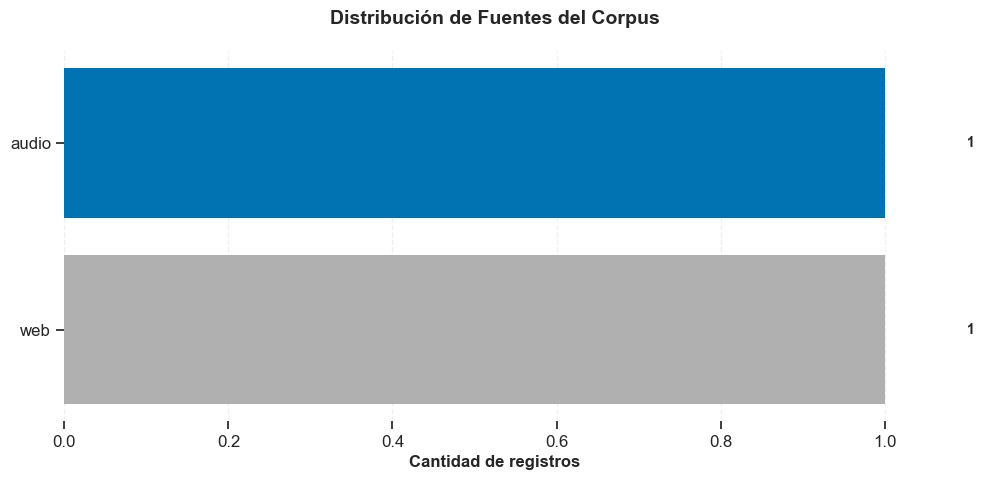

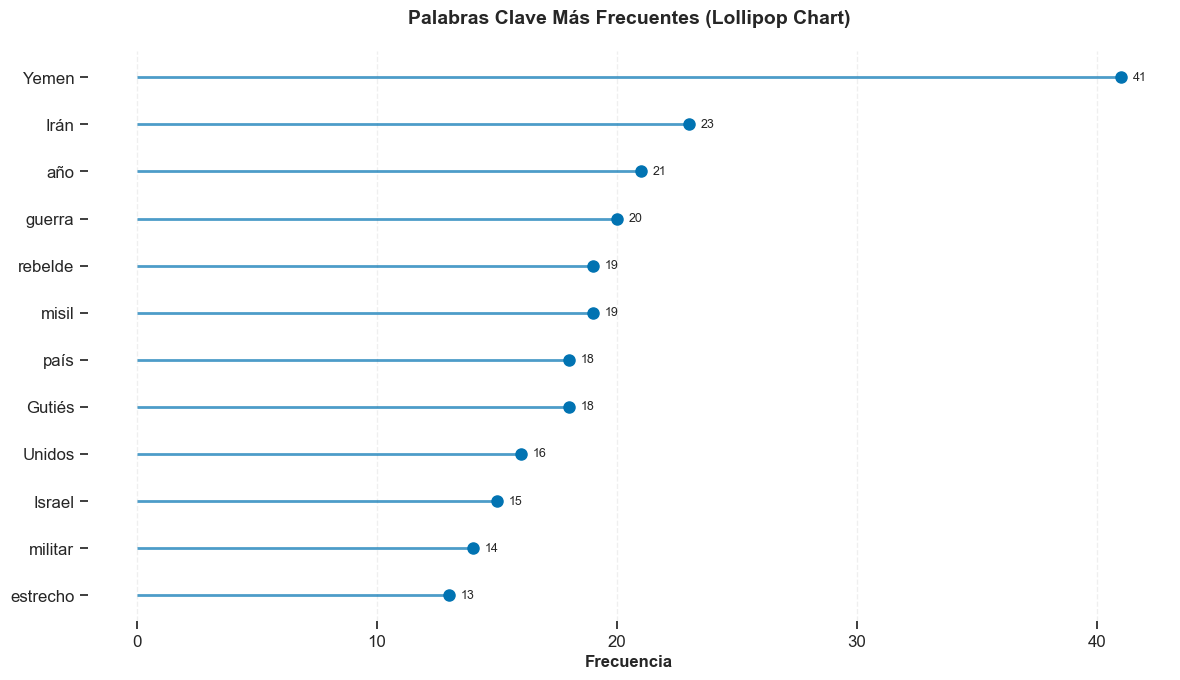

In [16]:
fig1 = visualizar_origen(df_corpus)
plt.show()

# Visualización 2: Palabras clave (Lollipop)
palabras_clave = analizador.extraer_palabras_clave(15)
fig2 = visualizar_palabras_clave_lollipop(palabras_clave, top_n=12)
plt.show()

# Visualización 3: Entidades (Plotly)
entidades = analizador.extraer_entidades()
fig3 = visualizar_entidades_plotly(entidades)
fig3.show()

> **Pausa de auditoría:**
> Revisá tu visualización. ¿Es accesible? El uso de la paleta 'colorblind' asegura que ciertos grados de daltonismo no impidan la lectura cromática, pero ¿el tamaño de fuente y la proporción de la figura se leen correctamente sin forzar la vista? ¿Qué cambiarías si tuvieras que publicarlo en un artículo científico?

## Parte 4: Pipeline Integrado (Orquestación)

**Objetivo:** Orquestar los componentes desarrollados en un flujo lógico unificado y persistir los hallazgos en formato estructurado. Todo sistema analítico debe poder guardar su estado final de forma estática.

In [18]:
class PipelineMediatico:
    def __init__(self, urls_web=None, url_audio=None, ruta_json=None):
        self.urls_web = urls_web or []
        self.url_audio = url_audio
        self.ruta_json = ruta_json
        self.df = None
        self.analizador = None
        
    def ejecutar_pipeline(self):
        """Orquesta la adquisición, unificación y análisis"""
        # PASO 1: Orquestá las llamadas a las funciones de la Parte 1.
        print("=" * 70)
        print("INICIANDO PIPELINE MEDIÁTICO")
        print("=" * 70)
        
        # Adquisición multimodal
        print("\n[1/4] Adquiriendo datos de la web...")
        datos_web = extraer_noticias_web(self.urls_web)
        
        print("\n[2/4] Transcribiendo audio...")
        datos_audio = []
        if self.url_audio:
            datos_audio = transcribir_audio_youtube(self.url_audio)
        
        print("\n[3/4] Cargando JSON previo...")
        datos_json = []
        if self.ruta_json:
            datos_json = cargar_json_previo(self.ruta_json)
        
        # Unificación
        print("\n[4/4] Unificando corpus...")
        self.df = unificar_corpus(datos_web, datos_audio, datos_json)
        
        # PASO 2: Instanciá AnalizadorCorpus y derivale el DataFrame resultante para procesar.
        print("\n[5/5] Analizando corpus con spaCy...")
        self.analizador = AnalizadorCorpus(self.df)
        self.estadisticas = self.analizador.estadisticas_corpus()
        self.entidades = self.analizador.extraer_entidades()
        
        print("\n" + "=" * 70)
        print("✓ Pipeline ejecutado exitosamente")
        print("=" * 70)

        print("Pipeline ejecutado exitosamente.")
        
    def generar_reporte_y_exportar(self, ruta_csv="corpus_resultante.csv", ruta_json="estadisticas.json"):
        """Exporta el dataframe y un JSON analítico"""
        if self.df is None or self.analizador is None:
            print("✗ Error: El pipeline no ha sido ejecutado aún.")
            return
        
        print("\nExportando resultados...")
        
        # PASO 3: Persistí self.df como CSV.
        # ¡OJO! La columna 'doc' de spaCy no es serializable, deberías dropearla o extraer sus textos antes de guardar.
        
        df_export = self.df.drop(columns=['doc'])
        df_export.to_csv(ruta_csv, index=False, encoding='utf-8')
        print(f"✓ Corpus exportado a: {ruta_csv}")
        
        # PASO 4: Persistí las estadísticas y el diccionario de entidades devueltas por el Analizador como JSON local.
        
        # Preparar datos para JSON
        reporte_json = {
            'metadata': {
                'fecha_generacion': pd.Timestamp.now().isoformat(),
                'total_documentos': len(self.df),
                'origenes': self.df['origen'].value_counts().to_dict()
            },
            'estadisticas_generales': self.estadisticas,
            'entidades_nombradas': {
                label: {
                    'total_menciones': data['total_menciones'],
                    'entidades_unicas': data['entidades_unicas'],
                    'top_10': [{'entidad': ent, 'frecuencia': freq} 
                              for ent, freq in data['top_10']]
                }
                for label, data in self.entidades.items()
            },
            'verbos_principales': [
                {'verbo': verbo, 'frecuencia': freq}
                for verbo, freq in self.analizador.extraer_verbos_principales(15)
            ],
            'palabras_clave': [
                {'palabra': palabra, 'frecuencia': freq}
                for palabra, freq in self.analizador.extraer_palabras_clave(20)
            ]
        }
        
        with open(ruta_json, 'w', encoding='utf-8') as f:
            json.dump(reporte_json, f, ensure_ascii=False, indent=2)
        print(f"✓ Estadísticas exportadas a: {ruta_json}")

# ---- Espacio para pruebas ----
pipeline = PipelineMediatico(
    urls_web=["https://www.infobae.com/estados-unidos/2026/04/20/trump-ratifico-que-mantendra-el-bloqueo-naval-a-iran-hasta-alcanzar-un-acuerdo-estan-perdiendo-500-millones-de-dolares-al-dia/"],
    url_audio="https://www.youtube.com/watch?v=jp6hIpJ41co",
    ruta_json=None
)

pipeline.ejecutar_pipeline()
pipeline.generar_reporte_y_exportar()
print("\nArchivos generados:")
print("  - corpus_resultante.csv")
print("  - estadisticas.json")

INICIANDO PIPELINE MEDIÁTICO

[1/4] Adquiriendo datos de la web...
Descargando: https://www.infobae.com/estados-unidos/2026/04/20/trump-ratifico-que-mantendra-el-bloqueo-naval-a-iran-hasta-alcanzar-un-acuerdo-estan-perdiendo-500-millones-de-dolares-al-dia/
✓ Extraído exitosamente

[2/4] Transcribiendo audio...
Descargando audio de: https://www.youtube.com/watch?v=jp6hIpJ41co
Extrayendo información del video...
[youtube] Extracting URL: https://www.youtube.com/watch?v=jp6hIpJ41co
[youtube] jp6hIpJ41co: Downloading webpage


[youtube] jp6hIpJ41co: Downloading android vr player API JSON
[info] jp6hIpJ41co: Downloading 1 format(s): 140
[download] Destination: temp_audio.m4a
[download] 100% of   24.79MiB in 00:00:01 at 13.47MiB/s    
[FixupM4a] Correcting container of "temp_audio.m4a"
Audio descargado: temp_audio.m4a
Transcribiendo con Whisper...


c:\Users\Alvaro Ortiz\Desktop\Procesamiento del lenguaje\ortiz-alvaro-pln-1c-2026\TPs\004_tpi_1\.venv\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Archivo temporal limpiado
✓ Transcripción completada (29023 caracteres)

[3/4] Cargando JSON previo...

[4/4] Unificando corpus...

--- CORPUS CONSOLIDADO ---
Total de registros: 2
Orígenes: {'web': 1, 'audio': 1}
Columnas: ['titulo_o_fuente', 'texto', 'origen', 'fecha']

[5/5] Analizando corpus con spaCy...
Cargando modelo de lenguaje...
Procesando los textos con spaCy...
✓ 2 textos procesados y almacenados en columna 'doc'

✓ Pipeline ejecutado exitosamente
Pipeline ejecutado exitosamente.

Exportando resultados...
✓ Corpus exportado a: corpus_resultante.csv
✓ Estadísticas exportadas a: estadisticas.json

Archivos generados:
  - corpus_resultante.csv
  - estadisticas.json


> **Pausa de auditoría:**
> Imaginá que un equipo de periodismo de datos de tu facultad te pide el corpus procesado. ¿Qué información necesitaban ellos en el CSV plano versus qué preferiste consolidar en el JSON jerárquico? Pensá por qué separamos esas dos naturalezas de exportación y registralo.

## Parte 5: Dashboard Interactivo con Gradio

**Objetivo:** Diseñar una interfaz interactiva que reaccione dinámicamente frente al usuario, conectando el backend analítico con componentes preconstruidos de frontend.

> [!IMPORTANT]
> **Dilema de diseño**
> ¿Qué componentes elegirías para cada salida? Pedile a la IA tres layouts de estructura (por ejemplo: Pestañas vs. Columna vertical vs. Acordeón) para tu dashboard. Elegí el que consideres mejor para la experiencia de lectura evaluativa y descartá explícitamente los otros dos argumentando tu postura técnica.

**Escribí tu justificación acá:**
Elegí la navegaciónpor pestañas ya que no satura la vista al tener secciones independientes, se puede ver que datos se están visualizando y tener al usuario enfocado.

In [20]:
# PASO 1: Diseñá el bloque principal de gr.Blocks() interactuando con los métodos de la clase AnalizadorCorpus.
# Sugerencia: Utilizá pestañas (gr.Tab) para separar "Métricas Generales" de "Filtros e Interacción".

def filtrar_contexto_entidad(query, analizador_obj):
    """
    Busca una entidad en el corpus y devuelve las oraciones donde aparece
    """
    if not query or len(query.strip()) == 0:
        return "Ingresá una entidad para buscar."
    
    query_lower = query.lower()
    resultados = []
    
    for idx, doc in enumerate(analizador_obj.df['doc']):
        # Buscar en el texto completo
        if query_lower in doc.text.lower():
            # Extraer las oraciones (sents) que contienen la entidad
            for sent in doc.sents:
                if query_lower in sent.text.lower():
                    resultados.append({
                        'doc_id': idx,
                        'titulo': analizador_obj.df.iloc[idx]['titulo_o_fuente'],
                        'oración': sent.text.strip()
                    })
    
    if not resultados:
        return f"No se encontraron menciones de '{query}' en el corpus."
    
    # Formatear resultados
    salida = f"**{len(resultados)} menciones encontradas de '{query}':**\n\n"
    for i, res in enumerate(resultados[:10], 1):  # Top 10
        salida += f"{i}. **[{res['titulo']}]** \n   {res['oración']}\n\n"
    
    if len(resultados) > 10:
        salida += f"\n*... y {len(resultados) - 10} menciones más.*"
    
    return salida

with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:
    gr.Markdown("""
    # 📊 Explorador de Agenda Mediática
    
    **Sistema integrado de adquisición, análisis lingüístico y visualización de corpus mediático.**
    
    Desarrollado con spaCy, Trafilatura, Whisper y Gradio.
    """)
    
    with gr.Tab("Panorama y Métricas"):
        gr.Markdown("## Estadísticas Generales del Corpus")
        
        with gr.Row():
            with gr.Column():
                # Mostrar estadísticas en formato tabla
                stats = analizador.estadisticas_corpus()
                stats_df = pd.DataFrame([
                    ["Total de tokens", f"{stats['total_tokens']:,}"],
                    ["Vocabulario único", f"{stats['vocabulario_unico']:,}"],
                    ["Total de oraciones", f"{stats['total_oraciones']:,}"],
                    ["Promedio tokens/doc", f"{stats['promedio_tokens_por_doc']:.2f}"],
                    ["Promedio oraciones/doc", f"{stats['promedio_oraciones_por_doc']:.2f}"]
                ], columns=["Métrica", "Valor"])
                
                gr.DataFrame(value=stats_df, label="Estadísticas Generales")
        
    with gr.Tab("Explorador de Entidades"):
        gr.Markdown("## Entidades Nombradas por Tipo")
        
        # Visualización interactiva de entidades
        entidades = analizador.extraer_entidades()
        fig3 = visualizar_entidades_plotly(entidades)
        gr.Plot(value=fig3, label="Entidades por Categoría")
        
        gr.Markdown("---")
        gr.Markdown("## Búsqueda de Contexto")
        
        # Textbox para buscar entidad
        query_input = gr.Textbox(
            label="Ingresá una palabra o entidad",
            placeholder="Ej: Trump, Estados Unidos, gobierno",
            lines=1
        )
        
        search_btn = gr.Button("🔎 Buscar Contexto", variant="primary")
        
        # Output con las oraciones encontradas
        output_text = gr.Markdown(value="Ingresá una entidad y presioná 'Buscar' para ver contextos.")
        
        # Conectar botón a función
        search_btn.click(
            fn=lambda q: filtrar_contexto_entidad(q, analizador),
            inputs=query_input,
            outputs=output_text
        )
        
        # Tabla con entidades clasificadas
        gr.Markdown("---")
        gr.Markdown("## Ranking de Entidades Principales")
        
        with gr.Row():
            for label in ['PER', 'ORG', 'LOC']:
                if label in entidades and entidades[label]['top_10']:
                    ents_data = pd.DataFrame(
                        entidades[label]['top_10'],
                        columns=["Entidad", "Frecuencia"]
                    )
                    gr.DataFrame(value=ents_data, label=f"Entidades {label}")

    with gr.Tab("📥 Exportación y Metadatos"):
        gr.Markdown("## Información del Corpus")
        
        # Metadatos
        metadata = {
            'Total de documentos': len(df_corpus),
            'Orígenes': ', '.join(f"{k}: {v}" for k, v in df_corpus['origen'].value_counts().to_dict().items()),
            'Fecha de análisis': pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
            'Modelo spaCy': 'es_core_news_lg'
        }
        
        meta_text = "\n\n".join([f"**{k}:** {v}" for k, v in metadata.items()])
        gr.Markdown(meta_text)
        
        gr.Markdown("---")
        gr.Markdown("## Archivos Generados")
        
        gr.Markdown("""
        Los siguientes archivos fueron exportados:
        
        - **corpus_resultante.csv**: Corpus procesado sin metadatos lingüísticos
        - **estadisticas.json**: Reporte completo con análisis, entidades y frecuencias
        
        Estos archivos están listos para importar en herramientas BI o análisis posterior.
        """)
        
        # Botón para descargar (simulado)
        gr.Button("📊 Descargar Reporte JSON", variant="secondary")
        gr.Button("📄 Descargar Corpus CSV", variant="secondary")

# Descomentá la siguiente línea cuando el bloque esté terminado
dashboard_medios.launch()

C:\Users\Alvaro Ortiz\AppData\Local\Temp\ipykernel_6584\86615669.py:39: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


---
## Cierre Formal y Checklist de Entrega

1. ¿Corriste el pipeline de principio a fin, comprobando que las funciones se anidan y comparten el DataFrame correctamente?
2. ¿Tu *AI Reflection Log* evidencia que cuestionaste a la IA y al modelo algorítmico, o todas tus celdas dicen "me devolvió un código y lo usé"?
3. ¿Revisaste el impacto visual de los gráficos garantizando que minimizan la "tinta algorítmica" (Data-Ink Ratio)?
4. ¿Justificaste tus decisiones de arquitectura técnica en el código de orquestación y exportación?

Si respondiste positivamente: felicitaciones, completaste el **TPI 1** demostrando un uso constructivo de la IA, asumiendo un rol profesional capaz de dirigir la automatización de forma estratégica e informada.